# Transient Debye-Waller Effect

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dschick/udkm1Dsim/blob/develop/examples/05-xrays/02-dynamical_xray_debye_waller.ipynb)

In this notebook the transient Debye-Waller effect is examplified.
Due to a change in sample temperature also the x-ray scattering intensity can change.
Similar to thermal properties, also the `deb_wal_fac` property of {py:class}`Layer <udkm1Dsim.structures.layers.Layer>`s can have multiple elements
to be assigned to temperatures of different sub-systems in the sample.

:::{versionadded} 2.3.0
Temperature-dependence of Debye-Waller factor with example {py:class}`XrayDyn <udkm1Dsim.simulations.xrays.XrayDyn>`
:::

:::{admonition} Reference {cite}`pudell2026`
:class: seealso
J.-E. Pudell, et al., *Ultrafast x-ray thermometry: Contrasting strain and Debye-Waller effects in platinum thin films*, [Phys. Rev. B 113, L220301 (2026)](https://doi.org/10.1103/x46h-3kdb) 
:::

Please refer to the [dynamical-X-ray-scattering example](dynamical_xray.ipynb) for more details on only strain dependent scattering.

## Setup

Do all necessary imports and settings.

In [1]:
try:
    import udkm1Dsim as ud
except ImportError:
    %pip install udkm1Dsim[parallel]
    import udkm1Dsim as ud

u = ud.u  # import the pint unit registry from udkm1Dsim
import scipy.constants as constants
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
u.setup_matplotlib()  # use matplotlib with pint units

## Structure

Refer to the [structure example](#example_structure) for more details.

In [2]:
Mg = ud.Atom('Mg')
O  = ud.Atom('O')
Pt = ud.Atom('Pt')

In [3]:
# c-axis lattice constants
c_Pt = 0.22649*u.nm
c_MgO = 0.421272*u.nm

# Platinum layer
prop_Pt = {}
prop_Pt['heat_capacity'] = ['740/21450*T',
                            '(23.8992 +7.89939e-3*T -3.77463e-6*T**2'
                            '+ 1.53451e-9*T**3 -27697.5/(T**2))/(195.084/1000.0)']
prop_Pt['therm_cond'] = ['(71-5)*(T[0]/T[1])',
                         5 * u.W/(u.m * u.K)]
Pt_sub_system_coupling_formula = '-7.09e-3*T_0**5 +3.64e2*T_0**4-7.30e6*T_0**3+7.29e10*T_0**2-3.85e14*T_0+12.046e17'
prop_Pt['sub_system_coupling'] = ['-0.5*({:s})*(T_0-T_1)'.format(Pt_sub_system_coupling_formula),
                                  '-0.5*({:s})*(T_1-T_0)'.format(Pt_sub_system_coupling_formula)] 
prop_Pt['lin_therm_exp'] = ['2.22e-9*T',
                            '(1.300e-13*T**5 + -4.176e-10*T**4 + 5.179e-07*T**3 '
                            '- 3.088e-04*T**2 + 9.093e-02*T + 9.343e+00)*1e-6 - 2.22e-9*T']
prop_Pt['sound_vel'] = 3.95*u.nm/u.ps
prop_Pt['opt_ref_index'] = 2.55+6.35j
prop_Pt['a_axis'] = c_Pt
prop_Pt['b_axis'] = c_Pt / 0.77
prop_Pt['deb_wal_fac'] = ['0',
                          '(0.02938 + 0.1090e-2*T + 0.4310e-6*(T**2) - 0.4681e-9*(T**3) + 0.1829e-12*(T**4))/(8*pi**2)*1e-20']

Pt_layer = ud.UnitCell('Pt', 'Platinum', c_Pt, **prop_Pt)
Pt_layer.add_atom(Pt, 0)

# MgO substrate
prop_MgO = {}
prop_MgO['heat_capacity'] = [0.00001, 877]
prop_MgO['therm_cond'] = [0,
                          '2.42e4 * (T**-1.114) /1.25']
prop_MgO['sub_system_coupling'] = ['-1.0e17*(T_0-T_1)',
                                   '1.0e17*(T_0-T_1)']
prop_MgO['lin_therm_exp'] = [0,
                             '1.61*(1.664e-13*T**5 + -5.689e-10*T**4'
                             '+ 7.591e-07*T**3 + -4.935e-04*T**2 + 1.633e-01*T'
                             '+ -1.033e+01)*1e-6']
prop_MgO['sound_vel'] = 9.12*u.nm/u.ps
prop_MgO['opt_ref_index'] = 1.7222
prop_MgO['deb_wal_fac'] = [0, 0]

MgO_sub = ud.UnitCell('MgO', 'MgO', c_MgO, **prop_MgO)
MgO_sub.add_atom(Mg, 0)
MgO_sub.add_atom(O, 0)
MgO_sub.add_atom(Mg, 0)
MgO_sub.add_atom(O, 0)
MgO_sub.add_atom(Mg, 0.5)
MgO_sub.add_atom(O, 0.5)
MgO_sub.add_atom(Mg, 0.5)
MgO_sub.add_atom(O, 0.5)

Number of subsystems changed from 1 to 2.
Number of subsystems changed from 1 to 2.


:::{attention}
The number of elements of the `deb_wal_fac` property is not checked and must not be equal to `num_sub_system`.
This helps for backwards compatibility and decouples {py:class}`Heat <udkm1Dsim.simulations.heat.Heat>` and {py:class}`XrayDyn <udkm1Dsim.simulations.xrays.XrayDyn>` simulations.
:::

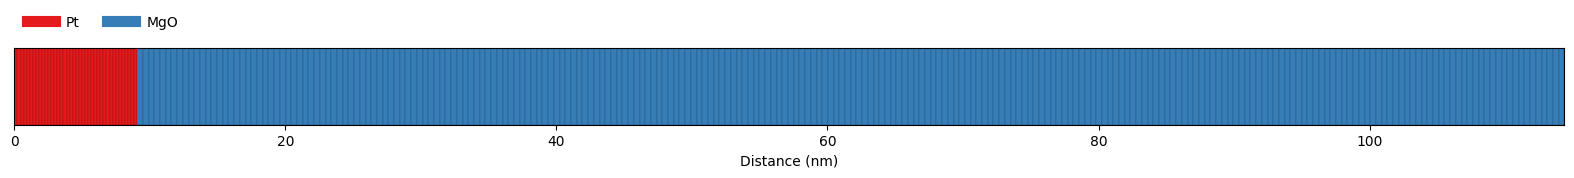

Structure properties:

Name   : Pt on MgO substrate
Thickness : 114.4 nm
Roughness : 0 nm
----
40 times Platinum: 9.06 nm
250 times MgO: 105.3 nm
----
no substrate



In [4]:
S = ud.Structure('Pt on MgO substrate')

S.add_sub_structure(Pt_layer, 40)
S.add_sub_structure(MgO_sub, 250)

S.visualize()
print(S)

## Heat

Refer to the [excitation & NTM example](#example_excitation_NTM) for more details.

In [5]:
h = ud.Heat(S, True)

h.save_data = False
h.disp_messages = True

h.excitation = {'fluence': [5]*u.mJ/u.cm**2,
                'delay_pump':  [0]*u.ps,
                'pulse_width':  [0.6]*u.ps,
                'multilayer_absorption': True,
                'polarization': 'p',
                'wavelength': 1030*u.nm,
                'theta': 55*u.deg}

# enable heat diffusion
h.heat_diffusion = True

init_temp = 450
# set the boundary conditions
h.boundary_conditions = {'top_type': 'isolator',
                         'bottom_type': 'temperature',
                         'bottom_value': [init_temp, init_temp]*u.K
                         }

# temporal and spatial grid
delays = np.r_[-10:-1:3,
               -1:5:0.25,
               np.logspace(np.log10(5), np.log10(500), num=50)
               ]*u.ps
_, _, distances = S.get_distances_of_layers()

### Laser Absorption Profile

Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 35.8 % and transmission of 31.7 %.


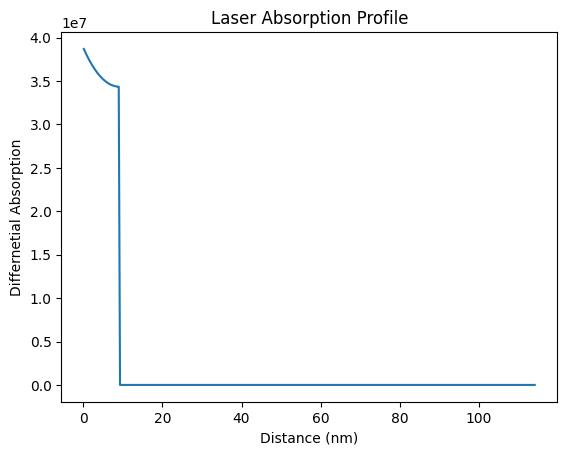

In [6]:
plt.figure()
dAdz, _, _, _ = h.get_multilayers_absorption_profile()
plt.plot(distances.to('nm'), dAdz)
plt.xlabel('Distance (nm)')
plt.ylabel('Differnetial Absorption')
plt.title('Laser Absorption Profile')
plt.show()

### Temperature Map

In [7]:
temp_map, delta_temp_map = h.get_temp_map(delays, init_temp*u.K)

Surface incidence fluence scaled by factor 0.8192 due to incidence angle theta=55.00 deg
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 1.859041 s
Calculating _heat_diffusion_ for excitation 1:1 ...
Absorption profile is calculated by multilayer formalism with p-polarization.
Total reflectivity of 35.8 % and transmission of 31.7 %.


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_ with 1 excitation(s): 11.590104 s
Calculating _heat_diffusion_ without excitation...


0it [00:00, ?it/s]

Elapsed time for _heat_diffusion_: 16.310005 s
Elapsed time for _temp_map_: 29.845057 s


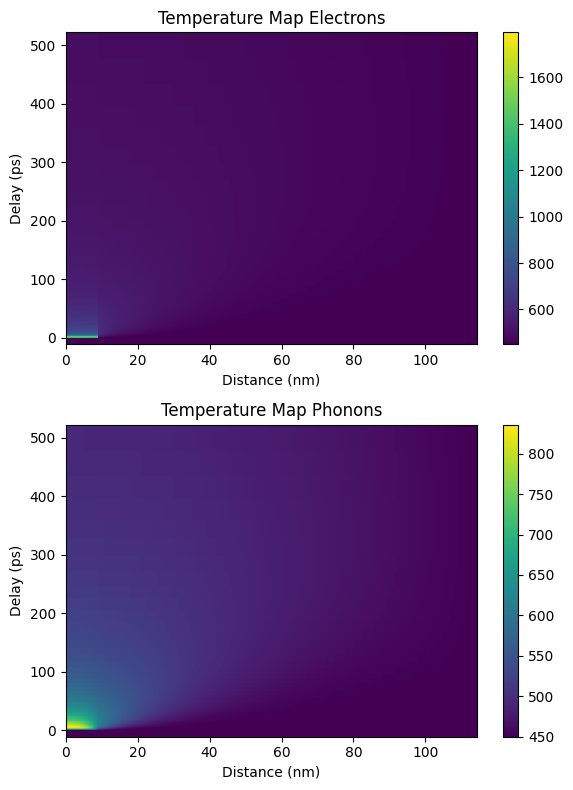

In [8]:
plt.figure(figsize=[6, 8])
plt.subplot(2, 1, 1)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude, temp_map[:, :, 0],
               shading='auto')
plt.colorbar()
plt.xlabel('Distance (nm)')
plt.ylabel('Delay (ps)')
plt.title('Temperature Map Electrons')

plt.subplot(2, 1, 2)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude, temp_map[:, :, 1],
               shading='auto')
plt.colorbar()
plt.xlabel('Distance (nm)')
plt.ylabel('Delay (ps)')
plt.title('Temperature Map Phonons')

plt.tight_layout()
plt.show()

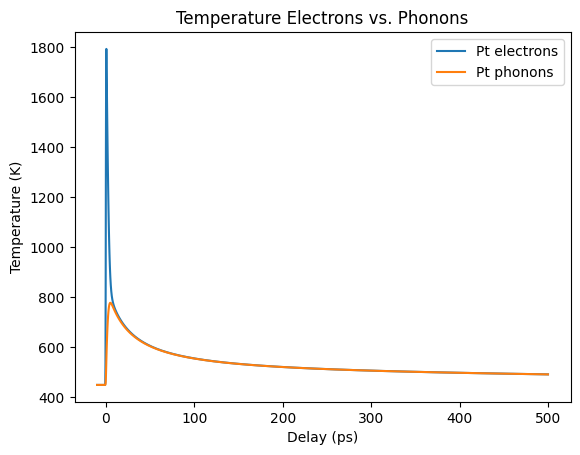

In [9]:
plt.figure()
select_Pt = S.get_all_positions_per_unique_layer()['Pt']
plt.plot(delays.to('ps'), np.mean(temp_map[:, select_Pt, 0], 1), label='Pt electrons')
plt.plot(delays.to('ps'), np.mean(temp_map[:, select_Pt, 1], 1), label='Pt phonons')
plt.ylabel('Temperature (K)')
plt.xlabel('Delay (ps)')
plt.legend()
plt.title('Temperature Electrons vs. Phonons')
plt.show()

## Numerical Phonons

Refer to the [strain pulse example](#example_strain_pulses) for more details.

In [10]:
p = ud.PhononNum(S, True)
p.save_data = False
p.disp_messages = True


:::{Attention}
We do NOT calculate coherent acoustic phonons (sound waves) here, but only thermal expansion.
:::

In [11]:

p.only_heat = True

In [12]:
strain_map = p.get_strain_map(delays, temp_map, delta_temp_map)

Calculating linear thermal expansion ...
Elapsed time for _strain_map_: 0.020957 s


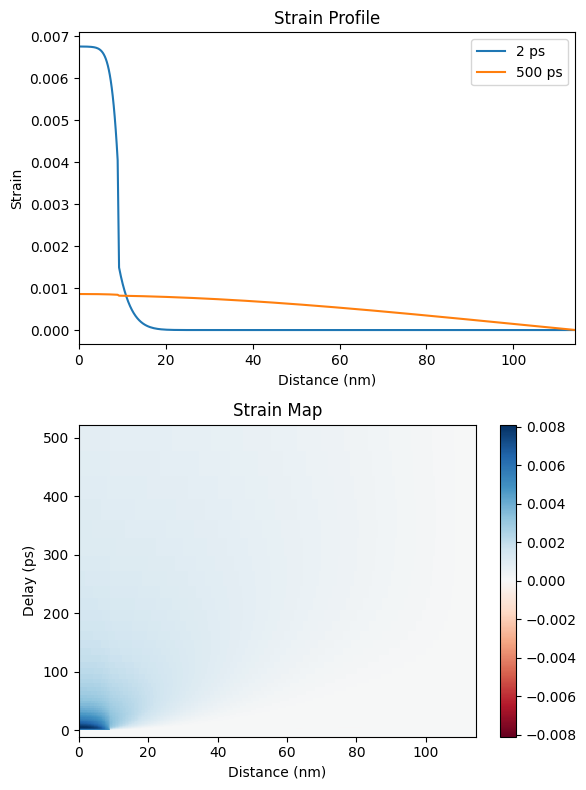

In [13]:
plt.figure(figsize=[6, 8])
plt.subplot(2, 1, 1)
plt.plot(distances.to('nm').magnitude, strain_map[13, :], label=np.round(delays[13]))
plt.plot(distances.to('nm').magnitude, strain_map[-1, :], label=np.round(delays[-1]))
plt.xlim([0, distances.to('nm').magnitude[-1]])
plt.xlabel('Distance (nm)')
plt.ylabel('Strain')
plt.legend()
plt.title('Strain Profile')

plt.subplot(2, 1, 2)
plt.pcolormesh(distances.to('nm').magnitude, delays.to('ps').magnitude,
               strain_map, cmap='RdBu', vmin=-np.max(strain_map),
               vmax=np.max(strain_map), shading='auto')
plt.colorbar()
plt.xlabel('Distance (nm)')
plt.ylabel('Delay (ps)')
plt.title('Strain Map')

plt.tight_layout()
plt.show()

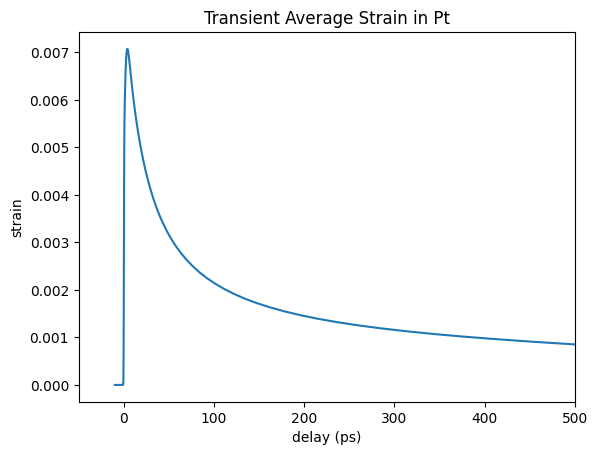

In [14]:
plt.figure()
plt.plot(delays.to('ps').magnitude, np.mean(strain_map[:, select_Pt], 1))
plt.ylabel('strain')
plt.xlabel('delay (ps)')
plt.xlim([-50, 500])
plt.title('Transient Average Strain in Pt')
plt.show()

## Initialize dynamical X-ray simulation

In [15]:
dyn = ud.XrayDyn(S, True)
dyn.disp_messages = True
dyn.save_data = False

incoming polarizations set to: sigma
analyzer polarizations set to: unpolarized


## Homogeneous X-ray scattering

For the case of homogeneously strained and/or heated samples, the dynamical X-ray scattering simulations can be greatly simplified, which saves a lot of computational time.

:::{attention}
When you provide a temperature-dependent `deb_wal_fac` property, {py:class}`XrayDyn <udkm1Dsim.simulations.xrays.XrayDyn>` simulations are carried out at `0 K` by default.
You can provide different temperatures both for `homogeneous_reflectivity` and `inhomogeneous_reflectivity`, see below.
:::

Calculating _homogenous_reflectivity_ ...
Elapsed time for _homogenous_reflectivity_: 0.014777 s


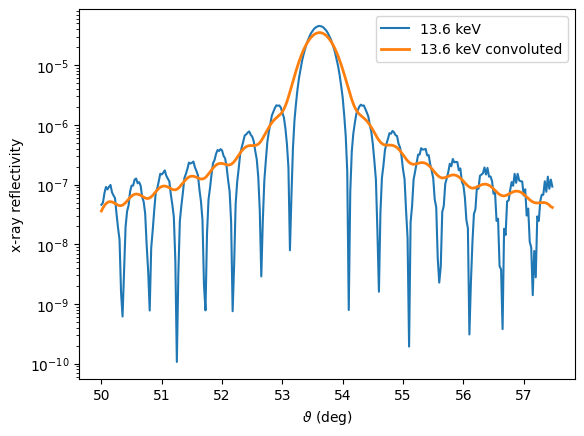

In [16]:
dyn.energy = np.r_[13600]*u.eV  # set photon energy
dyn.theta = np.r_[50:57.5:0.025]*u.degree  # set theta range

R_hom, A = dyn.homogeneous_reflectivity()

#instrument function / mosaicity of sample
FWHM = 0.05/1e-10  # Angstrom
sigma = FWHM/2.3548

def handle(x): return np.exp(-((x)/sigma)**2/2)
y_conv = dyn.conv_with_function(R_hom[0, :], dyn._qz[0, :], handle)

plt.figure()
plt.semilogy(dyn.theta[0, :]/1, R_hom[0, :], label='{}'.format(dyn.energy[0].to('keV')))
plt.semilogy(dyn.theta[0, :], y_conv, label='{} convoluted'.format(dyn.energy[0].to('keV')), lw=2)
plt.ylabel('x-ray reflectivity')
plt.xlabel(r'$\vartheta$ (deg)')
plt.legend()
plt.show()


Here we can already apply strains and temperatures - but only an average value per layer.

Calculating _homogenous_reflectivity_ ...
Elapsed time for _homogenous_reflectivity_: 0.012761 s
Calculating _homogenous_reflectivity_ ...
Elapsed time for _homogenous_reflectivity_: 0.012814 s
Calculating _homogenous_reflectivity_ ...
Elapsed time for _homogenous_reflectivity_: 0.012501 s


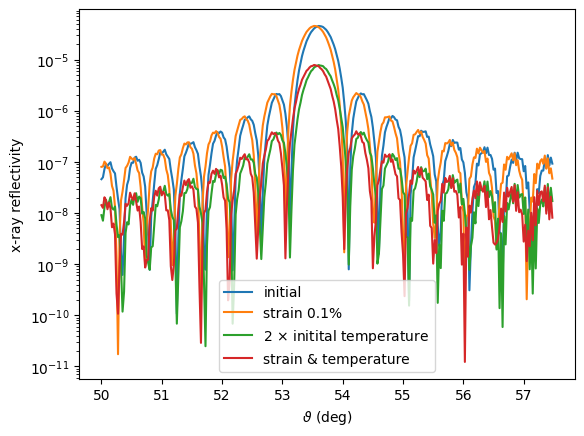

In [17]:
plt.figure()
plt.semilogy(dyn.theta[0, :]/1, R_hom[0, :], label='initial')

R_hom, A = dyn.homogeneous_reflectivity(strains=[0.001, 0.001])
plt.semilogy(dyn.theta[0, :]/1, R_hom[0, :], label='strain 0.1%')

R_hom, A = dyn.homogeneous_reflectivity(temps=np.array([[0, 2*init_temp], [0, 0]]))
plt.semilogy(dyn.theta[0, :]/1, R_hom[0, :], label=r'2 $\times$ initital temperature')

R_hom, A = dyn.homogeneous_reflectivity(strains=[0.001, 0.001], temps=np.array([[0, 2*init_temp], [0, 0]]))
plt.semilogy(dyn.theta[0, :]/1, R_hom[0, :], label=r'strain & temperature')

plt.ylabel('x-ray reflectivity')
plt.xlabel(r'$\vartheta$ (deg)')
plt.legend()
plt.show()


## Inhomogeneous X-ray scattering

For this simulation we cannot rely on providing `strain_vectors` to speed things up.
It is hence beneficial to run this simulations in `parallel` mode.

In [18]:
try:
    from dask.distributed import Client
    client = Client()
    R_seq = dyn.inhomogeneous_reflectivity(strain_map, temp_map=temp_map, calc_type='parallel',
                                           dask_client=client)
except:
    R_seq = dyn.inhomogeneous_reflectivity(strain_map, temp_map=temp_map, calc_type='sequential')

Calculating _inhomogeneousReflectivity_ ...
Elapsed time for _inhomogeneous_reflectivity_: 43.809873 s


Include experimental resolution

In [19]:
R_seq_conv = np.zeros_like(R_seq)
for i, delay in enumerate(delays):
    R_seq_conv[i, 0, :] = dyn.conv_with_function(R_seq[i, 0, :], dyn._qz[0, :], handle)

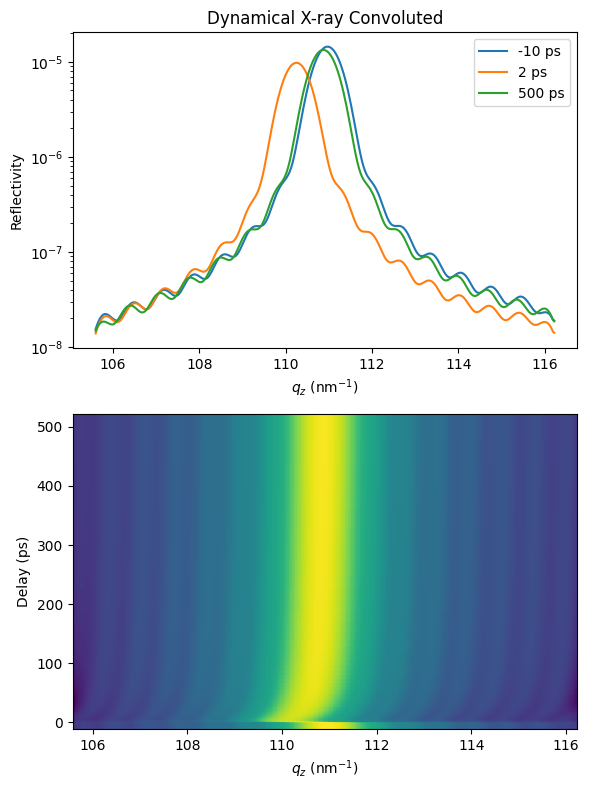

In [20]:
plt.figure(figsize=[6, 8])
plt.subplot(2, 1, 1)
plt.semilogy(dyn.qz[0, :].to('1/nm'), R_seq_conv[0, 0, :], label=np.round(delays[0]))
plt.semilogy(dyn.qz[0, :].to('1/nm'), R_seq_conv[13, 0, :], label=np.round(delays[13]))
plt.semilogy(dyn.qz[0, :].to('1/nm'), R_seq_conv[-1, 0, :], label=np.round(delays[-1]))

plt.xlabel('$q_z$ (nm$^{-1}$)')
plt.ylabel('Reflectivity')
plt.legend()
plt.title('Dynamical X-ray Convoluted')

plt.subplot(2, 1, 2)
plt.pcolormesh(dyn.qz[0, :].to('1/nm').magnitude, delays.to('ps').magnitude,
               np.log10(R_seq_conv[:, 0, :]), shading='auto')
plt.ylabel('Delay (ps)')
plt.xlabel('$q_z$ (nm$^{-1}$)')

plt.tight_layout()
plt.show()

Extract the relative integrated peak intensity of the Pt layer due to the transient Debye-Waller effect.

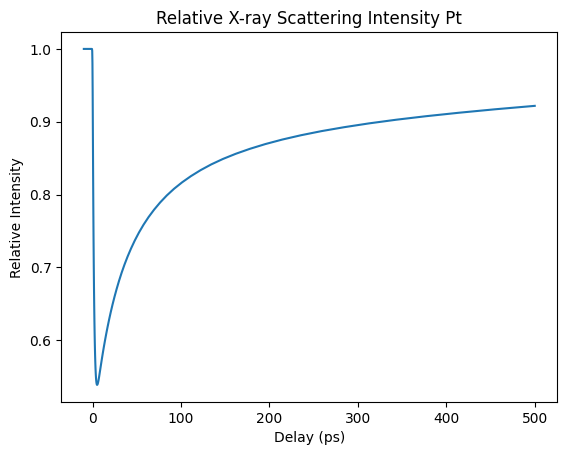

In [21]:
plt.figure()
plt.plot(delays.to('ps').magnitude, np.sum(R_seq_conv[:, 0, :],axis=1)/np.sum(R_seq_conv[0, 0, :]))
plt.title('Relative X-ray Scattering Intensity Pt');
plt.ylabel('Relative Intensity');
plt.xlabel('Delay (ps)');

## Gallery Plot

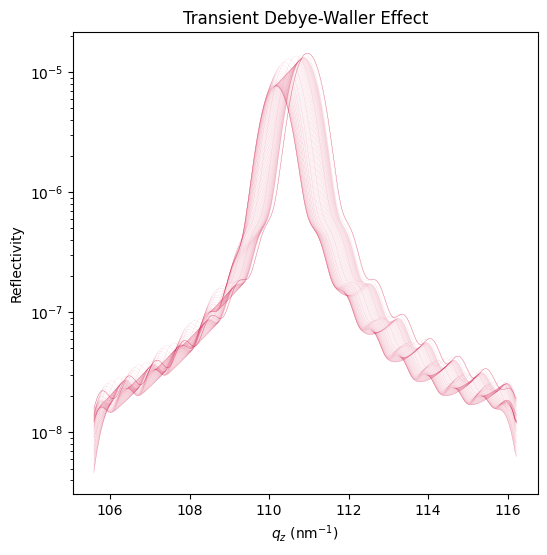

In [22]:
plt.figure(figsize=[6, 6])

for i, delay in enumerate(delays):
    plt.semilogy(dyn.qz[0, :].to('1/nm'), R_seq_conv[i, 0, :], color='#D71045', alpha=0.25, lw=0.15)

plt.xlabel('$q_z$ (nm$^{-1}$)')
plt.ylabel('Reflectivity')
plt.title('Transient Debye-Waller Effect')
plt.show()